In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [48]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\harsh\AppData\Local\Temp\ipykernel_14536\2173233649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=label, y=index, kind='bar', palette=color)


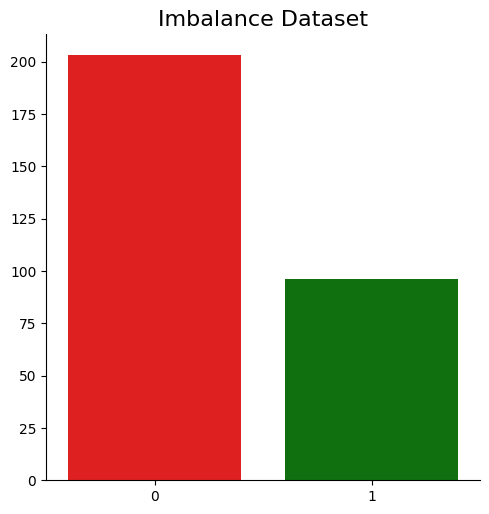

In [52]:
index = list((df['DEATH_EVENT'].value_counts().values)) # THIS IS THE COUNT OF EACH LABEL
label = list((df['DEATH_EVENT'].value_counts().keys())) # THIS IS THE LABELS
color= ['red', 'green']
sns.catplot(x=label, y=index, kind='bar', palette=color)
plt.title("Imbalance Dataset", fontsize=16)
plt.show()

In [53]:
dead = df[df['DEATH_EVENT']==0].loc[0:160]
not_dead = df[df['DEATH_EVENT']==1]

C:\Users\harsh\AppData\Local\Temp\ipykernel_14536\2568438172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x = list((balanced_df['DEATH_EVENT'].value_counts().keys())),


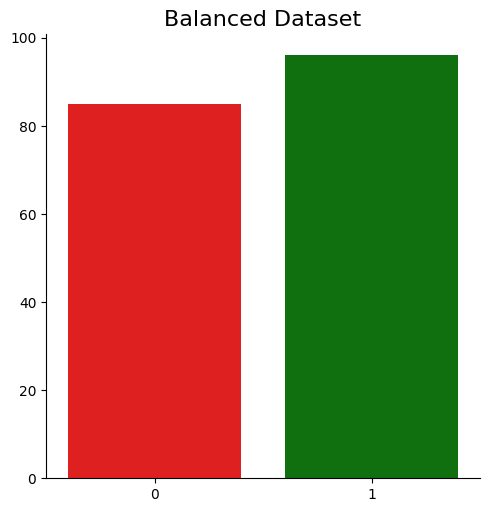

In [54]:
balanced_df = pd.concat([dead, not_dead])
colors = ['red', 'green']
sns.catplot(x = list((balanced_df['DEATH_EVENT'].value_counts().keys())),
y = list((balanced_df['DEATH_EVENT'].value_counts().values)),kind='bar', palette=colors)
plt.title("Balanced Dataset", fontsize=16) 
plt.show()

In [55]:
balanced_df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [56]:
df.drop('time', inplace=True, axis=1)

In [57]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,0


In [58]:
#splitting data into dependent and independent features
x = balanced_df.drop('DEATH_EVENT', axis=1)  
y = balanced_df['DEATH_EVENT']

In [59]:
print(x.shape)
print(y.shape)

(181, 12)
(181,)


In [60]:
#splitTING in train and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(144, 12)
(37, 12)
(144,)
(37,)


In [61]:
from sklearn.preprocessing import StandardScaler
st_scaler = StandardScaler()
x_train = st_scaler.fit_transform(x_train)
x_test = st_scaler.transform(x_test)

In [62]:
import tensorflow as tf

In [63]:
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.models import Sequential, load_model

ann_model = Sequential()
ann_model.add(Dense(units = 16, activation = 'relu', input_dim = x_train.shape[1]))
ann_model.add(Dense(units = 8, activation = 'relu'))
ann_model.add(Dense(units = 4, activation = 'relu'))

ann_model.add(Dense(units=1,activation='sigmoid'))

ann_model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

ann_model.summary()

c:\Users\harsh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history = ann_model.fit(x_train, y_train, batch_size = 32, epochs = 500, validation_split=0.2)

Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4957 - loss: 0.7004 - val_accuracy: 0.5862 - val_loss: 0.6791
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5043 - loss: 0.6955 - val_accuracy: 0.4483 - val_loss: 0.6791
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5043 - loss: 0.6911 - val_accuracy: 0.4483 - val_loss: 0.6792
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5304 - loss: 0.6879 - val_accuracy: 0.4483 - val_loss: 0.6795
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5304 - loss: 0.6842 - val_accuracy: 0.4483 - val_loss: 0.6798
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5478 - loss: 0.6811 - val_accuracy: 0.4483 - val_loss: 0.6800
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5565 - loss: 0.6775 - val_accuracy: 0.4483 - val_loss: 0.6803
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5565 - loss: 0.6746 - val_accuracy: 0.4483 - val_loss:

In [65]:
import pandas as pd
training_details = pd.DataFrame(history.history)
training_details

,accuracy,loss,val_accuracy,val_loss
0,0.495652,0.700445,0.586207,0.679124
1,0.504348,0.695506,0.448276,0.679097
2,0.504348,0.691144,0.448276,0.679187
3,0.530435,0.687874,0.448276,0.679468
4,0.530435,0.684184,0.448276,0.679797
...,...,...,...,...
495,1.000000,0.006018,0.793103,2.698710
496,1.000000,0.005977,0.793103,2.702471
497,1.000000,0.005941,0.793103,2.706059
498,1.000000,0.005913,0.793103,2.710165


In [66]:
y_test

83     0
109    0
113    1
154    0
72     1
78     0
89     0
141    0
31     1
37     1
8      1
148    1
142    0
67     1
114    0
79     0
121    0
46     1
11     1
128    0
12     1
40     1
68     1
96     0
64     0
194    1
132    0
81     0
82     1
195    1
27     1
127    0
65     1
47     1
138    0
95     0
36     1
Name: DEATH_EVENT, dtype: int64

<Axes: >

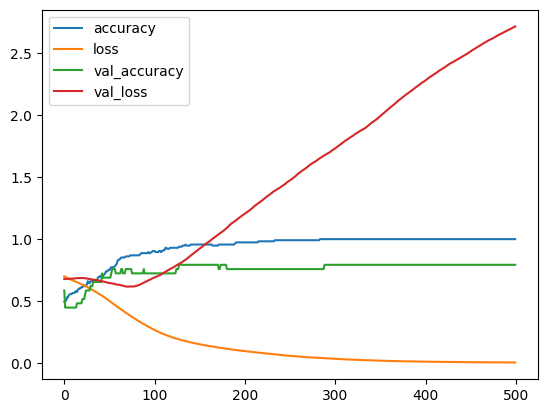

In [67]:
training_details.plot()

In [68]:
val_accuracy = np.mean(history.history['val_accuracy'])
print("\n%s: %.2f%%" % ('val_accuracy', val_accuracy*100))


val_accuracy: 75.32%


<Axes: >

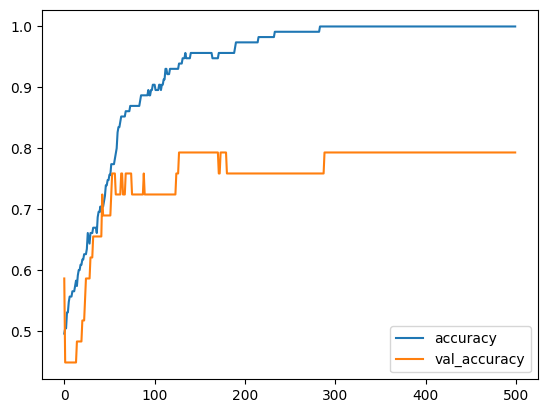

In [69]:
training_details[['accuracy', 'val_accuracy']].plot() #training accuracy vs validation accuracy

In [70]:
#get prediction probability
y_pred = ann_model.predict(x_test)
prediction_label = (y_pred > 0.5).astype("int").ravel()
prediction_label

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1])

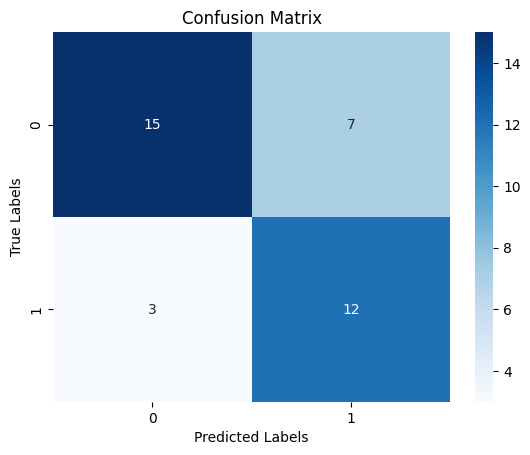

In [71]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

cm = confusion_matrix(prediction_label, y_test)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [72]:
print(classification_report(prediction_label, y_test))

              precision    recall  f1-score   support

           0       0.83      0.68      0.75        22
           1       0.63      0.80      0.71        15

    accuracy                           0.73        37
   macro avg       0.73      0.74      0.73        37
weighted avg       0.75      0.73      0.73        37



In [73]:
ann_model.save('heart_failure_prediction.h5') #save the model

#load the model
ann_model = load_model('heart_failure_prediction.h5')